In [1]:
import numpy as np

In [4]:
np.random.seed(42) 
# num time steps  
n_steps = 1000 

# define regumes 
# regime 0: calm (low mean, low vol) 
# regime 1: stressed (negative mean, high vol) 
regime_means = [0.0005, -0.001] 
regime_stds = [0.01, 0.03] 

# transition matrix: rows = current_state, cols = next state 
# P(stay calm) = 0.95, P(calm -> stressed) = 0.05 
# P(stressed -> calm) = 0.1, P(stay stressed) = 0.9 
transition_matrix = np.array([
    [0.95, 0.05],
    [0.1, 0.9]
]) 

# generate hidden state sequence 
states = np.zeros(n_steps, dtype=int) 
states[0] = 0 # initial state # calm regime 

for t in range(1, n_steps): 
    states[t] = np.random.choice(
        [0, 1], 
        p=transition_matrix[states[t - 1]]
    )

# generate returns from regime specific distributions 
returns = np.array([
    # typically, returns follow a log normal random walk  
    np.random.normal(regime_means[s], regime_stds[s]) for s in states 
]) 

prices = 100 * np.cumprod(1 + returns) 


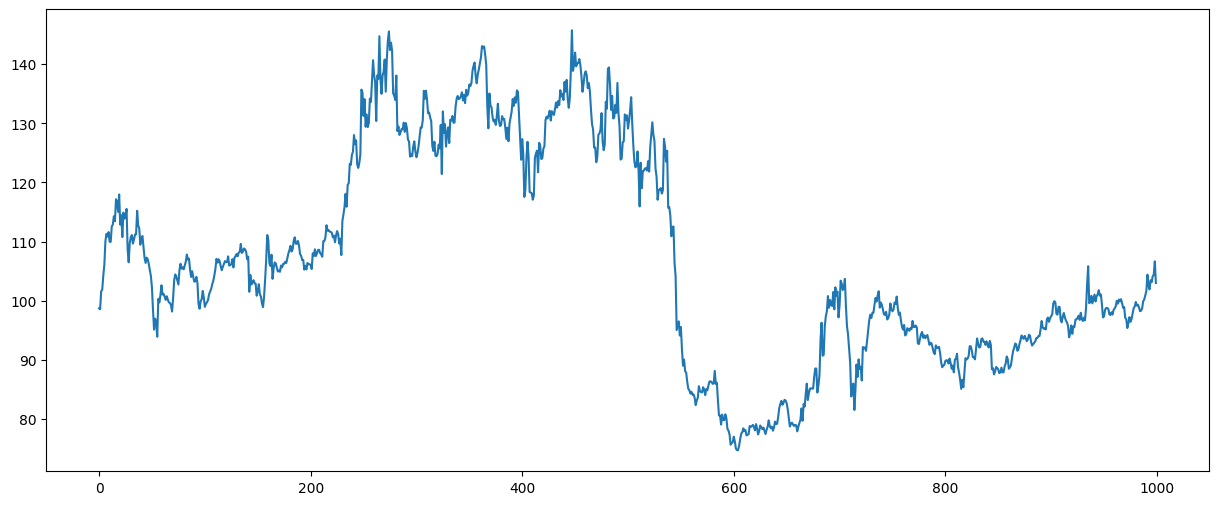

In [5]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(15, 6)) 
plt.plot(prices)

In [6]:
from hmmlearn.hmm import GaussianHMM 

# reshape returns for hmmlearn (needs 2D: n_samples x n_features)
X = returns.reshape(-1, 1) 

# fit 2-state gaussian hmm 
model = GaussianHMM(
    n_components=2, 
    covariance_type="full",
    n_iter=100, 
    random_state=42
)

model.fit(X) 
# decode the most likely state sequence
hidden_states = model.predict(X)

In [8]:
model.means_.flatten() 


array([ 0.0004036, -0.0002344])

In [10]:
print("Learned vs True Parameters")
print("Learned means:", model.means_.flatten())
print("True means: ", regime_means)

print("Learned stds:", np.sqrt(model.covars_.flatten()))
print("True stds: ", regime_stds)

print("Learned transition matrix:", model.transmat_)
print("True transition matrix:", transition_matrix)

Learned vs True Parameters
Learned means: [ 0.0004036 -0.0002344]
True means:  [0.0005, -0.001]
Learned stds: [0.01081056 0.0290957 ]
True stds:  [0.01, 0.03]
Learned transition matrix: [[0.96774315 0.03225685]
 [0.06781236 0.93218764]]
True transition matrix: [[0.95 0.05]
 [0.1  0.9 ]]


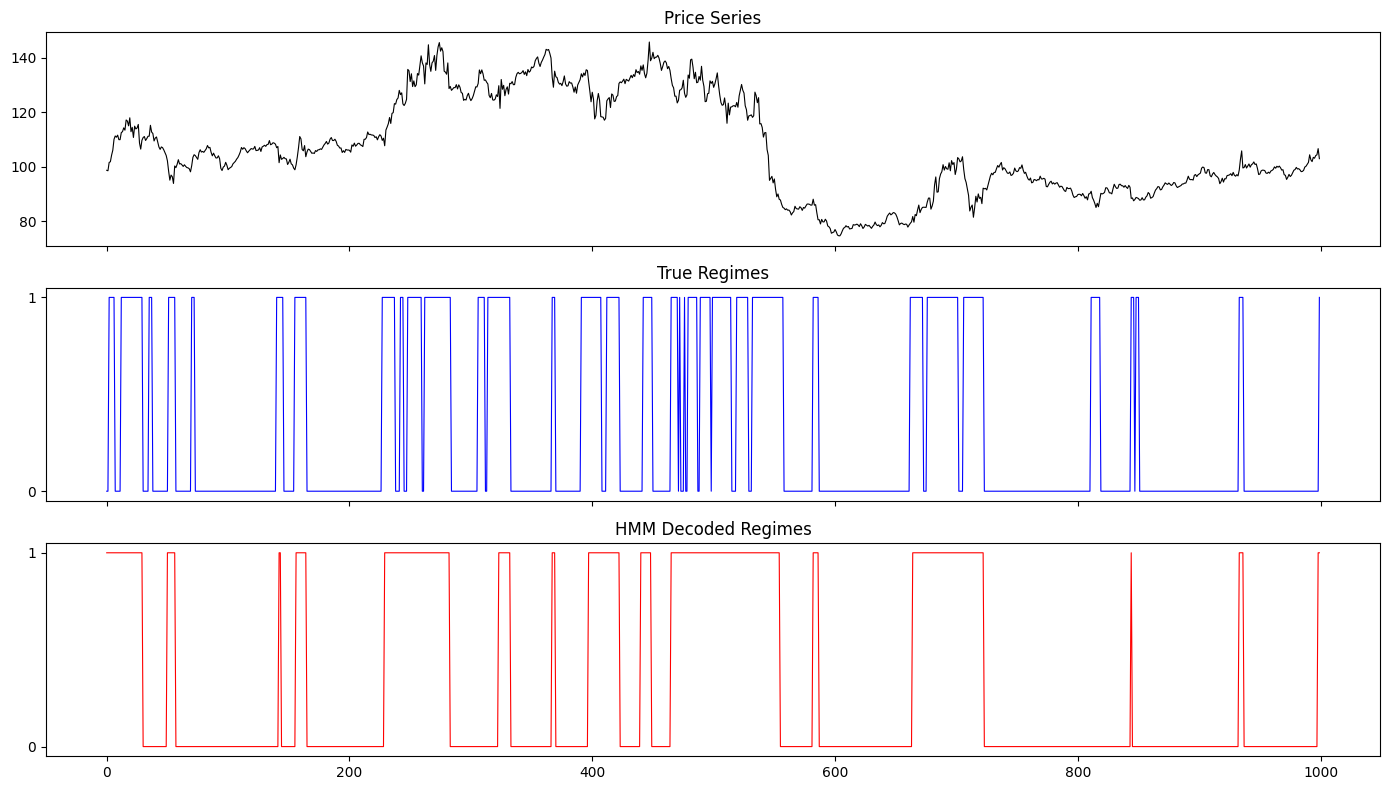

In [ ]:

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(prices, color='black', linewidth=0.8)
axes[0].set_title("Price Series")

axes[1].plot(states, color='blue', linewidth=0.8)
axes[1].set_title("True Regimes")
axes[1].set_yticks([0, 1])

axes[2].plot(hidden_states, color='red', linewidth=0.8)
axes[2].set_title("HMM Decoded Regimes")
axes[2].set_yticks([0, 1])

plt.tight_layout()
plt.show()